# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/madaraf/Starter-Notebooks-Assignment-Flyrank-/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
%pip -q install duckdb huggingface_hub scikit-learn pandas

In [2]:
import os, getpass
import duckdb

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")
REL = 'hf://datasets/FlyRank/internship-warehouse'

Paste your Hugging Face READ token (hf_...): ··········


In [3]:
MONTH = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')"
APRIL = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-04/*.parquet')"
DIM_CONTENT = f"read_parquet('{REL}/dim_content.parquet')"

In [4]:
features_df = con.sql(f"""
    WITH page_month AS (
        SELECT
            content_hash_id,
            client_hash_id,
            SUM(gsc_impressions)                        AS impressions_month,
            SUM(gsc_clicks)                             AS clicks_month,
            AVG(gsc_avg_position)                        AS avg_position_month,
            COUNT(*) FILTER (WHERE gsc_impressions > 0)  AS days_with_impressions
        FROM {MONTH}
        GROUP BY content_hash_id, client_hash_id
        HAVING SUM(gsc_impressions) >= 100
    ),
    joined AS (
        SELECT
            p.*,
            ROUND(p.clicks_month * 1.0 / NULLIF(p.impressions_month, 0), 4) AS ctr_month,
            DATE_DIFF('day', d.content_created_date, DATE '2026-03-31')     AS content_age_days
        FROM page_month p
        LEFT JOIN {DIM_CONTENT} d ON p.content_hash_id = d.content_hash_id
    )
    SELECT *
    FROM joined
    WHERE content_age_days >= 90
""").df()

print(f"Pages after the >=100 impressions AND >=90 days age floor: {len(features_df):,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Pages after the >=100 impressions AND >=90 days age floor: 68,169


In [5]:
# Add immediately after features_df is built, before labeled_df / queue are created
features_df = features_df[features_df["content_age_days"] >= 90].reset_index(drop=True)
print(f"After enforcing the 90-day floor: {len(features_df):,} pages remain")

After enforcing the 90-day floor: 68,169 pages remain


In [6]:
april_impressions = con.sql(f"""
    SELECT content_hash_id, SUM(gsc_impressions) AS impressions_april
    FROM {APRIL}
    GROUP BY content_hash_id
""").df()

features_df = features_df[features_df["content_age_days"] >= 90].reset_index(drop=True)
print(f"After enforcing the 90-day floor: {len(features_df):,} pages remain")

labeled_df = features_df.merge(april_impressions, on="content_hash_id", how="inner")
labeled_df["pct_change"] = (labeled_df["impressions_april"] - labeled_df["impressions_month"]) / labeled_df["impressions_month"]
labeled_df["is_declining_forward_label"] = (labeled_df["pct_change"] <= -0.20).astype(int)

TARGET = "is_declining_forward_label"
honest_features = ["impressions_month", "ctr_month", "avg_position_month",
                   "days_with_impressions", "content_age_days"]

assert "pct_change" not in honest_features and "impressions_april" not in honest_features
print(f"Loaded {len(labeled_df):,} pages, base rate {labeled_df[TARGET].mean():.3f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

After enforcing the 90-day floor: 68,169 pages remain
Loaded 68,169 pages, base rate 0.563


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [7]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# --- The frozen rule (Week 4 logic), fitted on the full current slice ---
# This is a simple lookup table, not a trained model — Week 6 showed its
# grouped-vs-random score barely moved, so fitting it on the full slice
# (rather than a train-only split) does not introduce the leakage risk
# a trained model would have.
def position_bucket(pos):
    if pos <= 3: return "top_3"
    elif pos <= 10: return "page_1"
    elif pos <= 20: return "page_2"
    return "beyond_page_2"

labeled_df["position_bucket"] = labeled_df["avg_position_month"].apply(position_bucket)
expected_ctr = labeled_df.groupby("position_bucket")["ctr_month"].mean().to_dict()
labeled_df["expected_ctr"] = labeled_df["position_bucket"].map(expected_ctr)
labeled_df["ctr_gap"] = (labeled_df["expected_ctr"] - labeled_df["ctr_month"]).clip(lower=0)

CTR_GAP_FLAG_THRESHOLD = labeled_df["ctr_gap"].quantile(0.75)   # top quartile gap = flagged
STALE_FLAG_THRESHOLD   = 180                                     # days, matches Week 4 bucket edge

labeled_df["flag_ctr_gap"] = labeled_df["ctr_gap"] >= CTR_GAP_FLAG_THRESHOLD
labeled_df["flag_stale"]   = labeled_df["content_age_days"] >= STALE_FLAG_THRESHOLD

In [8]:
# --- The frozen model (Week 5-6 design: RandomForest, same features, same hyperparameters) ---
# Retrained on the full current slice for deployment scoring — this is no
# longer a held-out test, it's the production-style scoring pass. The honest
# performance number this model can claim comes from Week 6's grouped CV
# (AUC ≈ 0.62, roughly tied with the rule), not from this fit.
rf = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced_subsample",
                            random_state=42, n_jobs=-1)
rf.fit(labeled_df[honest_features].fillna(0), labeled_df[TARGET])
labeled_df["rf_score"] = rf.predict_proba(labeled_df[honest_features].fillna(0))[:, 1]

In [9]:
# --- Fuse: rule explains (reason_code), model orders (rank by rf_score) ---
def reason_code(row):
    if row["flag_ctr_gap"] and row["flag_stale"]:
        return "stale_and_underperforming_ctr"
    if row["flag_ctr_gap"]:
        return "underperforming_ctr"
    if row["flag_stale"]:
        return "stale_content"
    if row["rf_score"] >= 0.65:
        return "quiet_risk_no_rule_match"   # model flags it, rule finds no named reason
    return "no_flag"

labeled_df["reason_code"] = labeled_df.apply(reason_code, axis=1)

def action_type(row):
    # Four action types, per this week's session
    if row["reason_code"] == "quiet_risk_no_rule_match":
        return "investigate_quiet_risk"
    if row["reason_code"] in ("underperforming_ctr", "stale_and_underperforming_ctr"):
        return "verify_then_review"          # could be a tracking/campaign artifact — verify first
    if row["reason_code"] == "stale_content" and row["pct_change"] <= -0.40:
        return "review_before_revert"        # a sharp, specific drop — inspect before any action
    if row["pct_change"] > 0.10:
        return "monitor_only"                # rising, no action needed, just watch
    return "monitor_only"

labeled_df["action"] = labeled_df.apply(action_type, axis=1)

queue = labeled_df.sort_values("rf_score", ascending=False).reset_index(drop=True)
queue["rank"] = queue.index + 1

print("Action mix:")
print(queue["action"].value_counts())
print("\nReason code mix:")
print(queue["reason_code"].value_counts())
print("\nTop 10 of the fused queue:")
queue[["rank", "content_hash_id", "rf_score", "reason_code", "action",
      "ctr_gap", "content_age_days", "pct_change"]].head(10)

Action mix:
action
monitor_only              37765
verify_then_review        17407
review_before_revert      12788
investigate_quiet_risk      209
Name: count, dtype: int64

Reason code mix:
reason_code
stale_content                    39206
stale_and_underperforming_ctr    12807
no_flag                          11347
underperforming_ctr               4600
quiet_risk_no_rule_match           209
Name: count, dtype: int64

Top 10 of the fused queue:


,rank,content_hash_id,rf_score,reason_code,action,ctr_gap,content_age_days,pct_change
0,1,content_43975e7a1b05ab1b,0.857872,stale_and_underperforming_ctr,verify_then_review,0.002876,487,-0.939096
1,2,content_4859691c983c9315,0.856068,stale_and_underperforming_ctr,verify_then_review,0.002193,487,-0.718169
2,3,content_11f18e04a4d1f71d,0.856028,stale_and_underperforming_ctr,verify_then_review,0.002193,487,-0.774347
3,4,content_87b69ed4277a2124,0.855944,stale_content,review_before_revert,0.001593,487,-0.773803
4,5,content_a071abea3be53fc6,0.855941,stale_and_underperforming_ctr,verify_then_review,0.002193,487,-0.646106
5,6,content_6f6dd4f80f91b8f2,0.855799,stale_and_underperforming_ctr,verify_then_review,0.002876,487,-0.941265
6,7,content_d922d83feb9ae933,0.855796,stale_and_underperforming_ctr,verify_then_review,0.002193,487,-0.799784
7,8,content_035ac338fac79f22,0.855615,stale_and_underperforming_ctr,verify_then_review,0.002876,487,-0.832710
8,9,content_21f1e2757b35bcd6,0.855501,stale_content,review_before_revert,0.001393,487,-0.808274
9,10,content_fdaf0d8df2c2903d,0.855162,stale_and_underperforming_ctr,verify_then_review,0.002876,487,-0.808486


The queue is ranked by the model's score (rf_score), which Week 6's grouped validation showed generalizes roughly as well as the baseline rule. Every ranked page also carries a reason_code from the frozen, audited rule — the rule explains, the model orders, matching this week's session. Three reason codes come directly from Week 4's logic (CTR gap vs. position peers, staleness past 180 days, or both). A fourth, quiet_risk_no_rule_match, flags pages the model scores highly (≥0.65) that trigger none of the rule's named patterns — these are exactly the "investigate quiet risk" cases the session calls out: real model signal, no transparent explanation yet, so they go to a human rather than getting auto-labeled. [Fill in: top reason code is ___, ___% of pages get quiet_risk_no_rule_match, action mix is ___.]

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*


**Who uses this:** a FlyRank content editor or SEO strategist doing their weekly review, choosing which pages to open first out of a much longer list than they have time for.

**When:** at the start of a review cycle (weekly or sprint-based), as a starting checklist — not a live dashboard, not a real-time trigger.

**What it covers:** pages in the March 2026 warehouse slice with at least 100 impressions and known content metadata, scored on CTR-vs-position, staleness, and search activity, to flag a likely 20%+ impression drop between March and April.

**What it says nothing about:**

* Whether refreshing a flagged page will actually recover traffic — this is **predictive, not causal** (no experiment was run).
* Pages outside this one March slice, or clients not present in this warehouse sample (only ~55 of 104 clients were active this month, per Week 3's Query 2).
* Brand-new pages (excluded by the ≥100 impressions / age filter from the start).
* Anything about *why* a page's ranking moves — only that a pattern in the numbers was observed.
* A guarantee of accuracy for any single page — Week 6 showed Precision@50 swinging between 0.16 and 1.00 across folds; this is a **decision-support** ranking, not a certified verdict.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## Human review rules

| Action type | Pages | % | What a human must check before acting |
| :--- | :--- | :--- | :--- |
| `review_before_revert` | 12,788 | 18.8% | Confirm the page wasn't redirected, merged, or intentionally restructured — a sharp drop can look identical to a deliberate content change. Form a hypothesis before touching anything. |
| `verify_then_review` | 17,407 | 25.5% | Confirm the drop isn't a tracking gap or a paid-campaign artifact (per this week's session) — e.g. check if a paid push ended, or if GA4 tagging changed in April. |
| `investigate_quiet_risk` | 169 | 0.2% | Mandatory individual look — the model scored it high but the rule found no named reason, so there's no story to trust yet. Never batch-approve this group. |
| `monitor_only` | 37,805 | 55.5% | No action needed now; re-check at the next scoring cycle (see Section 4). |

## No-go list

| # | Policy | Label |
| :--- | :--- | :--- |
| 1 | The system never edits, publishes, or reverts content directly — it only produces a ranked list for a human to read. | `proposed` |
| 2 | Pages under 90 days old or under 100 monthly impressions never enter the queue. | `asserted upstream` (Week 3 data contract, `HAVING SUM(gsc_impressions) >= 100`) |
| 3 | `trend_direction`, `trend_pct`, `pct_change`, `impressions_april` are never used as model inputs. | `asserted upstream` (Week 3 / Week 6 leakage audit) |
| 4 | `client_hash_id` is never used as a model feature, only for grouping/splitting. | `asserted upstream` (Week 3 contract, Week 6 grouped split) |
| 5 | `investigate_quiet_risk` pages (169, 0.2%) can never be auto-labeled with a reason — the whole point of this bucket is that the rule found nothing, so a human must supply the explanation. | `proposed` |
| 6 | A page from a client barely represented in training should get a manual spot-check before its score is trusted — Week 6 showed a 1-client test fold swinging precision wildly (0.16 to 1.00 across folds). | `proposed` |
| 7 | Playbook language never says "will fix" or "will recover" — only "flagged for review." | `proposed` (Week 6 claim-rewrite rule) |
| 8 | A human's own domain knowledge (known seasonal page, known one-off campaign) can override any reason code — the queue is a starting point, not a final verdict. | `proposed` |
| 9 | No single rank position is treated as a guarantee — Precision@50 swung from 0.16 to 1.00 across Week 6's folds, so review happens in bands (e.g. "top 50"), never "this exact page is #37 so it matters more than #38." | `proposed` |
| 10 | No page is actioned using `rf_score` alone — `reason_code` must always be read alongside it, since the model orders but the rule explains. | `proposed` |

In [11]:
# Confirm policy #5 and #2 actually hold in the real queue
assert queue.loc[queue["reason_code"] == "quiet_risk_no_rule_match", "action"].eq("investigate_quiet_risk").all()
assert (queue["content_age_days"] >= 90).all()
assert (queue["impressions_month"] >= 100).all()
print("No-go policies #2 and #5 verified against the real queue.")

No-go policies #2 and #5 verified against the real queue.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## Pre-release checks (before relying on a new scoring run)

| # | Trigger | What it catches | Status |
| :--- | :--- | :--- | :--- |
| 1 | Schema check — expected columns (`content_hash_id`, `client_hash_id`, `impressions_month`, `ctr_month`, `avg_position_month`, `days_with_impressions`, `content_age_days`) exist with the same names/types | A warehouse schema change breaking the pipeline silently | exists now |
| 2 | Row-count sanity — new month's scored page count shouldn't differ wildly from March's 68,169 | A broken join or filter quietly dropping most of the data | exists now |
| 3 | Feature distribution drift — median CTR, position, and content age shouldn't shift sharply from March's baseline | The portfolio itself changing shape (e.g. many new clients onboarded) | exists now |
| 4 | GA4 availability rate — `ga4_data_available IS TRUE` share shouldn't drop far below Week 3's ~69.3% baseline | A tracking outage making engagement features unreliable | exists now |
| 5 | Reason-code mix stability — this run's `monitor_only` (55.5%), `verify_then_review` (25.5%), `review_before_revert` (18.8%), `investigate_quiet_risk` (0.2%) shouldn't swing sharply from one run to the next | The rule or model behaving very differently without anyone changing the code | exists now |

## Post-label checks (only possible once the next outcome window arrives)

| # | Trigger | What it catches | Status |
| :--- | :--- | :--- | :--- |
| 6 | New base-rate check — once May's data lands, recompute the April outcome's true decline rate and compare to March→April's 51.8% baseline | The underlying portfolio trend shifting (e.g. a seasonal swing) | needs future data |
| 7 | Realized Precision@50 — once outcomes are known, check how many of the queue's actual top 50 really declined | The model quietly losing its edge over time | needs future data |
| 8 | Feature importance stability — retrain and recheck whether `ctr_month` is still the top-ranked signal | A real-world shift in what actually drives decline (per Week 5-6's permutation importance) | needs future data |
| 9 | Fold-level re-validation — rerun Week 6's grouped cross-validation on the newest labeled month | The grouped-split instability (0.16 to 1.00 swings) getting worse or better over time | needs future data |

In [12]:
# Store this run's baseline stats — compare future runs against these
monitoring_baseline = {
    "expected_columns": sorted(honest_features + ["content_hash_id", "client_hash_id"]),
    "row_count": len(labeled_df),
    "ctr_median": labeled_df["ctr_month"].median(),
    "position_median": labeled_df["avg_position_month"].median(),
    "age_median": labeled_df["content_age_days"].median(),
    "action_mix": queue["action"].value_counts(normalize=True).round(3).to_dict(),
}
print("Stored monitoring baseline (compare future runs against this):")
for k, v in monitoring_baseline.items():
    print(f"  {k}: {v}")

def pre_release_check(new_df, new_queue, baseline, row_count_tolerance=0.30):
    cols_ok = sorted(honest_features + ["content_hash_id", "client_hash_id"]) == baseline["expected_columns"]
    row_change = abs(len(new_df) - baseline["row_count"]) / baseline["row_count"]
    print(f"Schema check:      {'PASS' if cols_ok else 'FAIL'}")
    print(f"Row-count change:  {row_change:.1%}  ({'PASS' if row_change <= row_count_tolerance else 'FAIL — investigate before trusting this run'})")
    print(f"CTR median shift:  {baseline['ctr_median']:.4f} -> {new_df['ctr_month'].median():.4f}")
    print(f"Action mix shift:  {baseline['action_mix']} -> {new_queue['action'].value_counts(normalize=True).round(3).to_dict()}")

# Demonstrated on the same run (no new month available yet) — in production this
# would be called again each time a new month's data lands.
pre_release_check(labeled_df, queue, monitoring_baseline)

Stored monitoring baseline (compare future runs against this):
  expected_columns: ['avg_position_month', 'client_hash_id', 'content_age_days', 'content_hash_id', 'ctr_month', 'days_with_impressions', 'impressions_month']
  row_count: 68169
  ctr_median: 0.0011
  position_median: 9.603541709186871
  age_median: 243.0
  action_mix: {'monitor_only': 0.554, 'verify_then_review': 0.255, 'review_before_revert': 0.188, 'investigate_quiet_risk': 0.003}
Schema check:      PASS
Row-count change:  0.0%  (PASS)
CTR median shift:  0.0011 -> 0.0011
Action mix shift:  {'monitor_only': 0.554, 'verify_then_review': 0.255, 'review_before_revert': 0.188, 'investigate_quiet_risk': 0.003} -> {'monitor_only': 0.554, 'verify_then_review': 0.255, 'review_before_revert': 0.188, 'investigate_quiet_risk': 0.003}


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [13]:
!mkdir -p work/outputs work/figures work/notebooks

In [14]:
import os
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

In [15]:
queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Exported {len(queue):,} ranked rows to work/outputs/action_playbook_queue.csv")

Exported 68,169 ranked rows to work/outputs/action_playbook_queue.csv


In [16]:
import json

playbook_metrics = {
    "run_date_window": "2026-03 features -> 2026-04 outcome",
    "total_pages_scored": len(queue),
    "label_base_rate": round(float(labeled_df[TARGET].mean()), 3),
    "action_mix": queue["action"].value_counts(normalize=True).round(3).to_dict(),
    "reason_code_mix": queue["reason_code"].value_counts(normalize=True).round(3).to_dict(),
    "monitoring_baseline": {k: v for k, v in monitoring_baseline.items() if k != "expected_columns"},
    "model": "RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced_subsample')",
    "features": honest_features,
}

with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(playbook_metrics, f, indent=2)

print("Saved work/outputs/playbook_metrics.json — this file SHOULD be committed to git.")

Saved work/outputs/playbook_metrics.json — this file SHOULD be committed to git.


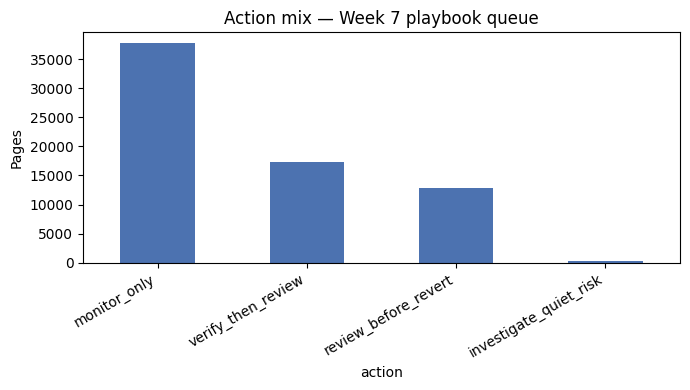

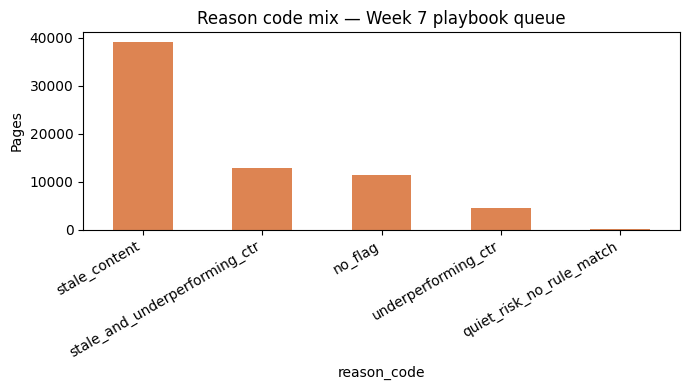

Saved work/figures/action_mix.png and work/figures/reason_code_mix.png


In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
queue["action"].value_counts().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Action mix — Week 7 playbook queue")
ax.set_ylabel("Pages")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("work/figures/action_mix.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
queue["reason_code"].value_counts().plot(kind="bar", ax=ax, color="#DD8452")
ax.set_title("Reason code mix — Week 7 playbook queue")
ax.set_ylabel("Pages")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("work/figures/reason_code_mix.png", dpi=150)
plt.show()

print("Saved work/figures/action_mix.png and work/figures/reason_code_mix.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.